# Customer Churn Prediction

## 1. Problem Statement

Customer churn occurs when a customer stops using a company’s service. This project predicts whether a telecom customer is likely to churn based on demographics, account details, subscribed services, and billing information.

## 2. Business Objective

The objective is to identify customers at risk of churn so that the telecom company can take proactive retention actions such as personalized offers, contract upgrades, and customer-support outreach.

## 3. Dataset Understanding

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

file_path = "../data/raw/Telco-Customer-Churn.csv"
df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)

print("\nDataset information:")
df.info()

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:


customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  70

### Initial Dataset Observations

- The dataset contains 7,043 customer records and 21 columns.
- `Churn` is the target variable. It indicates whether a customer left the telecom service.
- `customerID` is a unique identifier and will be removed before model training.
- The dataset contains both categorical and numerical features.
- `TotalCharges` is expected to be numerical, but it is currently stored as an object data type and will be corrected during data cleaning.

In [5]:
print("Churn value counts:")
display(df["Churn"].value_counts())

print("\nChurn percentage:")
display((df["Churn"].value_counts(normalize=True) * 100).round(2))

Churn value counts:


Churn
No     5174
Yes    1869
Name: count, dtype: int64


Churn percentage:


Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

In [6]:
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Target Variable Observation

- `Churn` is the target variable for this binary classification problem.
- `Yes` represents a customer who left the telecom service, while `No` represents a customer who stayed.
- The target classes are not equally distributed, so evaluation will include precision, recall, F1-score, and ROC-AUC in addition to accuracy.


## 4. Data Quality Checks and Cleaning

Before training models, we check whether the dataset has missing values, duplicate rows, incorrect data types, blank values, or unnecessary columns.

In [7]:
# Check missing values in every column
missing_values = df.isnull().sum()

print("Missing values per column:")
display(missing_values[missing_values > 0])

print("Total missing values:", missing_values.sum())

# Check duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Check number of unique values in each column
print("\nUnique values per column:")
display(df.nunique())

Missing values per column:


Series([], dtype: int64)

Total missing values: 0
Duplicate rows: 0

Unique values per column:


customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

### Data Quality Check Observation

- No standard null values were found in the dataset.
- Duplicate records were checked before preprocessing.
- Even when a dataset has no null values, text columns can contain blank strings. Therefore, `TotalCharges` will be checked separately because it should be numeric.

In [8]:
# Check blank or whitespace-only values in TotalCharges
blank_total_charges = df["TotalCharges"].astype(str).str.strip().eq("").sum()

print("Blank values in TotalCharges:", blank_total_charges)

# Show rows that contain blank TotalCharges values
display(df[df["TotalCharges"].astype(str).str.strip().eq("")])

Blank values in TotalCharges: 11


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [9]:
# Convert blank spaces to missing values, then convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"].astype(str).str.strip().replace("", np.nan),
    errors="coerce"
)

print("Data type after conversion:", df["TotalCharges"].dtype)
print("Missing values in TotalCharges after conversion:", df["TotalCharges"].isnull().sum())

display(df[df["TotalCharges"].isnull()])

Data type after conversion: float64
Missing values in TotalCharges after conversion: 11


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [10]:
# Check the tenure values for rows with missing TotalCharges
display(df.loc[df["TotalCharges"].isnull(), ["tenure", "MonthlyCharges", "TotalCharges", "Churn"]])

,tenure,MonthlyCharges,TotalCharges,Churn
488,0,52.55,NaN,No
753,0,20.25,NaN,No
936,0,80.85,NaN,No
1082,0,25.75,NaN,No
1340,0,56.05,NaN,No
3331,0,19.85,NaN,No
3826,0,25.35,NaN,No
4380,0,20.00,NaN,No
5218,0,19.70,NaN,No
6670,0,73.35,NaN,No


In [11]:
# New customers with tenure = 0 have not accumulated total charges yet.
# Therefore, fill missing TotalCharges values with 0.
df["TotalCharges"] = df["TotalCharges"].fillna(0)

print("Missing values in TotalCharges after filling:", df["TotalCharges"].isnull().sum())
print("TotalCharges data type:", df["TotalCharges"].dtype)

Missing values in TotalCharges after filling: 0
TotalCharges data type: float64


### TotalCharges Cleaning Decision

- `TotalCharges` contained blank values that were converted to missing values.
- These records belonged to customers with `tenure = 0`, meaning they were new customers.
- Since new customers have not accumulated any charges yet, missing `TotalCharges` values were filled with `0`.
- The column was converted from `object` to `float64` so it can be used by machine-learning models.

In [12]:
# customerID is only a unique identifier.
# It does not describe customer behavior, so remove it before analysis and modeling.
df = df.drop(columns="customerID")

print("Dataset shape after removing customerID:", df.shape)
print("Is customerID still present?", "customerID" in df.columns)

Dataset shape after removing customerID: (7043, 20)
Is customerID still present? False


In [13]:
print("Final missing values:", df.isnull().sum().sum())
print("Final duplicate rows:", df.duplicated().sum())
print("Final dataset shape:", df.shape)

display(df.head())

Final missing values: 0
Final duplicate rows: 22
Final dataset shape: (7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [14]:
# Save the cleaned dataset separately.
# The original file in data/raw remains unchanged.
cleaned_file_path = "../data/processed/cleaned_telco_churn.csv"

df.to_csv(cleaned_file_path, index=False)

print(f"Cleaned dataset saved successfully at: {cleaned_file_path}")

Cleaned dataset saved successfully at: ../data/processed/cleaned_telco_churn.csv


In [15]:
# Load the saved cleaned dataset to verify it
cleaned_df = pd.read_csv("../data/processed/cleaned_telco_churn.csv")

print("Saved cleaned dataset shape:", cleaned_df.shape)
print("Missing values:", cleaned_df.isnull().sum().sum())
display(cleaned_df.head())

Saved cleaned dataset shape: (7043, 20)
Missing values: 0


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Cleaning Summary

- Checked the dataset for standard missing values and duplicate rows.
- Identified blank values in `TotalCharges`, converted the column to numeric format, and filled missing values with `0` for new customers with `tenure = 0`.
- Removed `customerID` because it is only a unique identifier and does not provide predictive information.
- Saved the cleaned dataset separately in `data/processed/cleaned_telco_churn.csv`.
- The final cleaned dataset contains 7,043 rows and 20 columns with no missing values.

## 5. Exploratory Data Analysis

Exploratory Data Analysis is used to understand patterns, relationships, and churn behavior in the cleaned dataset. The goal is to identify customer segments with higher churn risk and generate business insights before model training.

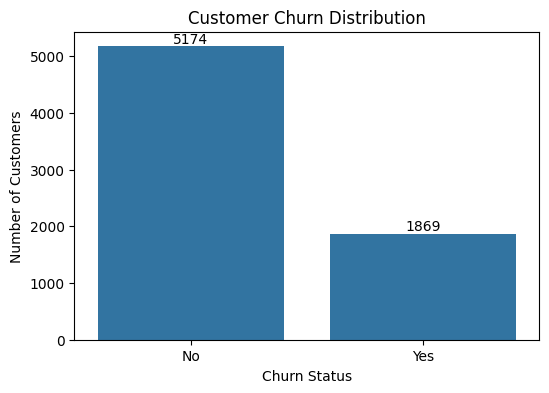

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


In [16]:
plt.figure(figsize=(6, 4))

ax = sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

print((df["Churn"].value_counts(normalize=True) * 100).round(2))

### Insight: Overall Churn Distribution

- Out of 7,043 customers, 5,174 customers (73.46%) did not churn and 1,869 customers (26.54%) churned.
- Although most customers stayed, more than one-fourth of customers left the telecom service, which is a meaningful business retention problem.
- The target variable is moderately imbalanced, so later model evaluation will use recall, F1-score, and ROC-AUC along with accuracy.

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


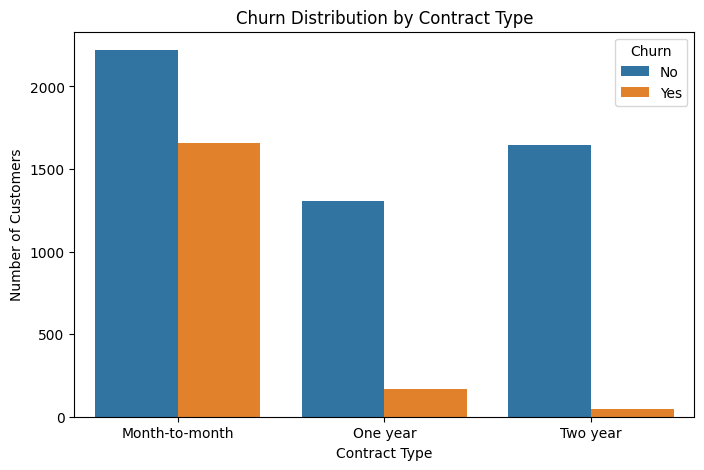

In [17]:
contract_churn_rate = (
    pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100
).round(2)

display(contract_churn_rate)

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Churn Distribution by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.legend(title="Churn")
plt.show()

### Insight: Contract Type and Churn

- Customers with month-to-month contracts had the highest churn rate: **42.71%**.
- Customers with one-year contracts had a much lower churn rate of **11.27%**.
- Customers with two-year contracts had the lowest churn rate: **2.83%**.
- This suggests that longer-term contracts are strongly associated with customer retention.
- A practical retention strategy would be to target month-to-month customers with incentives to upgrade to annual or two-year plans.

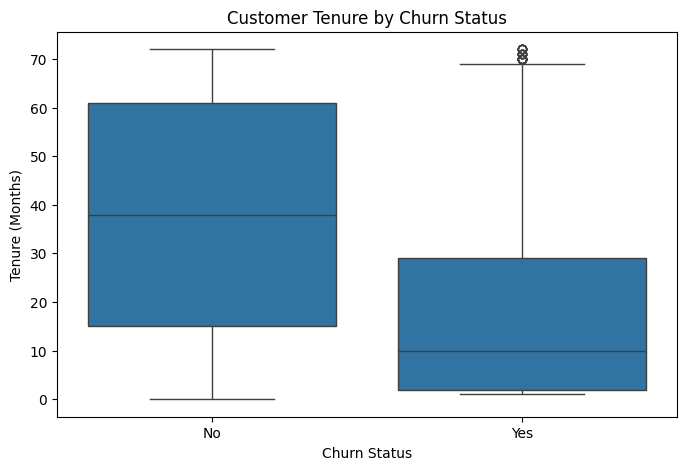

,count,mean,median,min,max
Churn,,,,,
No,5174,37.57,38.0,0,72
Yes,1869,17.98,10.0,1,72


In [18]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Customer Tenure by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Tenure (Months)")
plt.show()

tenure_summary = df.groupby("Churn")["tenure"].agg(
    ["count", "mean", "median", "min", "max"]
).round(2)

display(tenure_summary)

### Insight: Customer Tenure and Churn

- Customers who did not churn had an average tenure of **37.57 months** and a median tenure of **38 months**.
- Customers who churned had a much lower average tenure of **17.98 months** and a median tenure of **10 months**.
- This indicates that churn is much more common among newer customers, especially during the early months of their relationship with the company.
- Retention efforts should focus on onboarding, early customer support, and targeted offers during the first year.

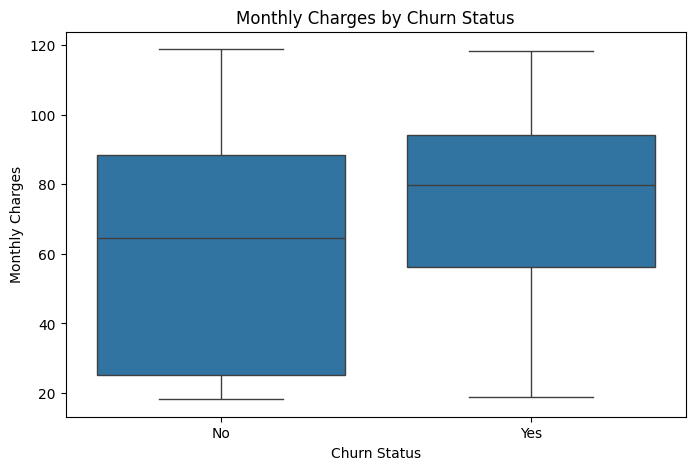

,count,mean,median,min,max
Churn,,,,,
No,5174,61.27,64.43,18.25,118.75
Yes,1869,74.44,79.65,18.85,118.35


In [19]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Monthly Charges")
plt.show()

monthly_charges_summary = df.groupby("Churn")["MonthlyCharges"].agg(
    ["count", "mean", "median", "min", "max"]
).round(2)

display(monthly_charges_summary)

### Insight: Monthly Charges and Churn

- Customers who churned had an average monthly charge of **74.44**, compared with **61.27** for customers who stayed.
- The median monthly charge was also higher for churned customers: **79.65** versus **64.43**.
- Higher monthly charges appear to be associated with greater churn risk.
- The company could investigate pricing, value perception, and plan benefits for higher-paying customers, then offer suitable discounts or plan alternatives.

Churn,No,Yes
InternetService,,
DSL,81.04,18.96
Fiber optic,58.11,41.89
No,92.60,7.40


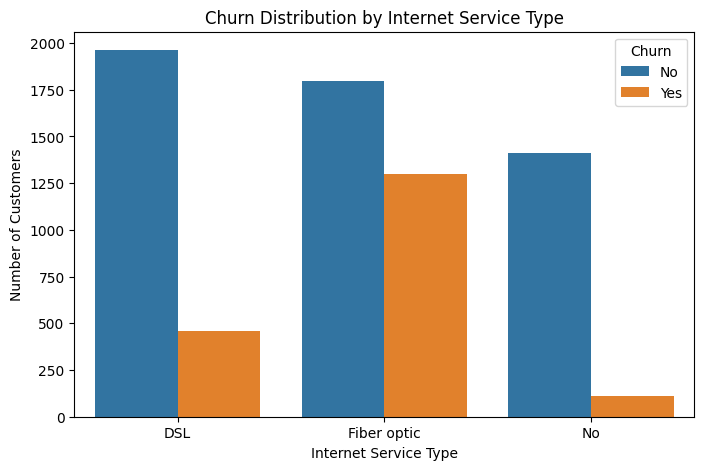

In [20]:
internet_churn_rate = (
    pd.crosstab(df["InternetService"], df["Churn"], normalize="index") * 100
).round(2)

display(internet_churn_rate)

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn"
)

plt.title("Churn Distribution by Internet Service Type")
plt.xlabel("Internet Service Type")
plt.ylabel("Number of Customers")
plt.legend(title="Churn")
plt.show()

### Insight: Internet Service Type and Churn

- Fiber optic customers had the highest churn rate at approximately **41.89%**.
- DSL customers had a lower churn rate of approximately **18.96%**.
- Customers with no internet service had the lowest churn rate at approximately **7.40%**.
- The high churn among fiber optic customers may indicate concerns related to pricing, service quality, competition, or customer expectations.
- The company should investigate the fiber optic customer experience and target this segment with retention offers or service-improvement initiatives.

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.29,16.71
Credit card (automatic),84.76,15.24
Electronic check,54.71,45.29
Mailed check,80.89,19.11


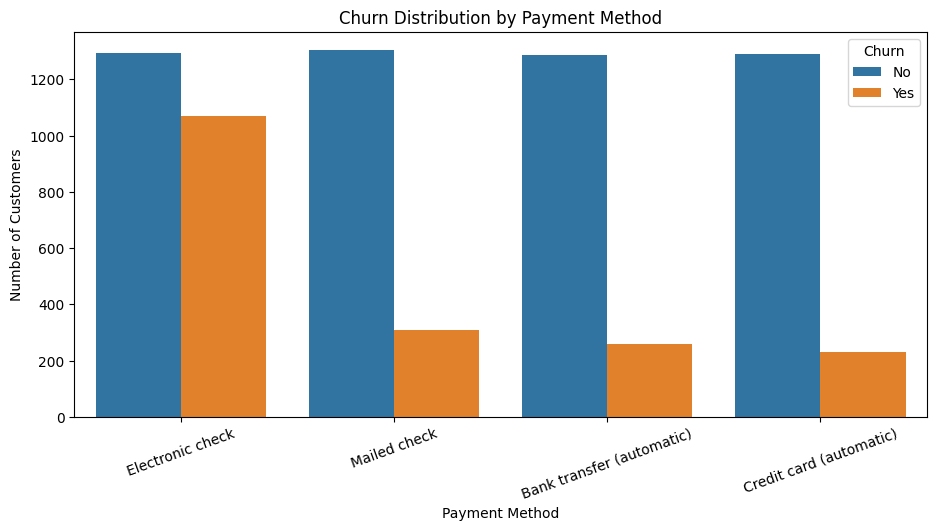

In [21]:
payment_churn_rate = (
    pd.crosstab(df["PaymentMethod"], df["Churn"], normalize="index") * 100
).round(2)

display(payment_churn_rate)

plt.figure(figsize=(11, 5))

sns.countplot(
    data=df,
    x="PaymentMethod",
    hue="Churn"
)

plt.title("Churn Distribution by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)
plt.legend(title="Churn")
plt.show()

### Insight: Payment Method and Churn

- Customers using **electronic check** had the highest churn rate at **45.29%**.
- Customers using **mailed check** had a churn rate of **19.11%**.
- Customers using automatic payments had lower churn rates:
  - **Bank transfer (automatic): 16.71%**
  - **Credit card (automatic): 15.24%**
- This suggests that automatic payment methods are associated with better customer retention.
- The company could encourage electronic-check customers to switch to automatic payment options through simple setup support or incentives.

In [22]:
service_columns = [
    "OnlineSecurity",
    "TechSupport",
    "DeviceProtection",
    "OnlineBackup"
]

for column in service_columns:
    churn_rate = (
        pd.crosstab(df[column], df["Churn"], normalize="index") * 100
    ).round(2)

    print(f"\nChurn rate by {column}:")
    display(churn_rate)


Churn rate by OnlineSecurity:


Churn,No,Yes
OnlineSecurity,,
No,58.23,41.77
No internet service,92.60,7.40
Yes,85.39,14.61



Churn rate by TechSupport:


Churn,No,Yes
TechSupport,,
No,58.36,41.64
No internet service,92.60,7.40
Yes,84.83,15.17



Churn rate by DeviceProtection:


Churn,No,Yes
DeviceProtection,,
No,60.87,39.13
No internet service,92.60,7.40
Yes,77.50,22.50



Churn rate by OnlineBackup:


Churn,No,Yes
OnlineBackup,,
No,60.07,39.93
No internet service,92.60,7.40
Yes,78.47,21.53


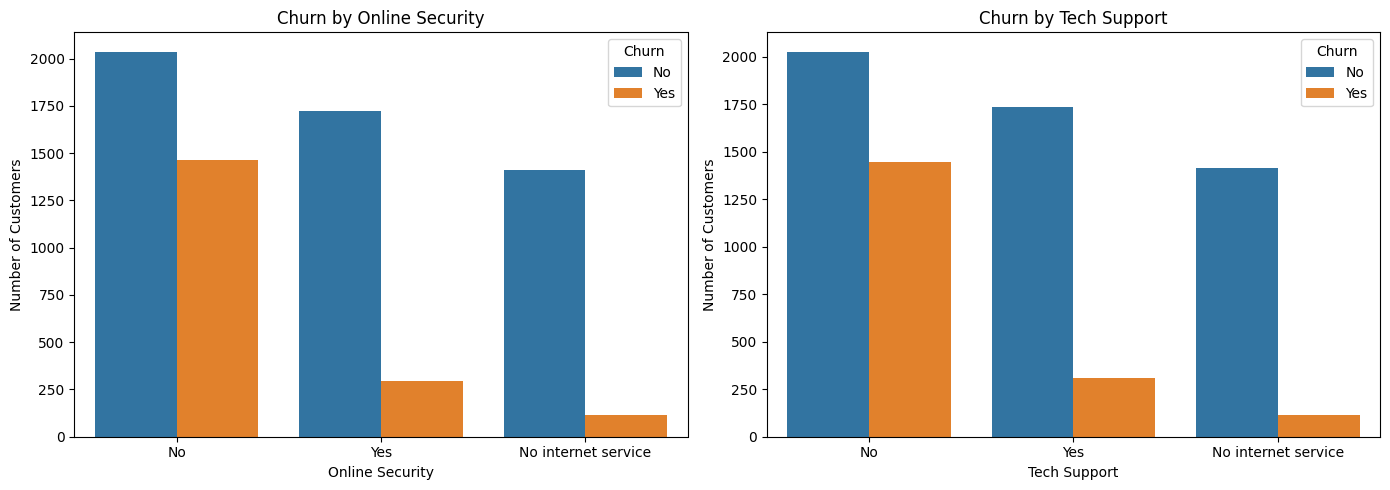

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(
    data=df,
    x="OnlineSecurity",
    hue="Churn",
    ax=axes[0]
)
axes[0].set_title("Churn by Online Security")
axes[0].set_xlabel("Online Security")
axes[0].set_ylabel("Number of Customers")
axes[0].legend(title="Churn")

sns.countplot(
    data=df,
    x="TechSupport",
    hue="Churn",
    ax=axes[1]
)
axes[1].set_title("Churn by Tech Support")
axes[1].set_xlabel("Tech Support")
axes[1].set_ylabel("Number of Customers")
axes[1].legend(title="Churn")

plt.tight_layout()
plt.show()

### Insight: Value-Added Services and Churn

- Customers without online security had a churn rate of **41.77%**, compared with **14.61%** for customers who had online security.
- Customers without tech support had a churn rate of **41.64%**, compared with **15.17%** for customers who had tech support.
- Online security and tech support are strongly associated with lower churn.
- The company can reduce churn by promoting these services through bundles, free trials, or targeted offers for high-risk customers.

### EDA Summary: Key Churn Drivers

The exploratory analysis identified several customer segments with higher churn risk:

- Month-to-month contract customers had the highest churn rate at 42.71%.
- Customers with shorter tenure were more likely to churn; churned customers had a median tenure of 10 months.
- Customers who churned had higher average monthly charges than customers who stayed.
- Fiber optic customers had a high churn rate of 41.89%.
- Electronic-check customers had the highest payment-method churn rate at 45.29%.
- Customers without online security or tech support had churn rates above 41%.

These findings suggest that the company should prioritize early-tenure customers, month-to-month customers, fiber optic users, electronic-check users, and customers without support-related services for retention campaigns.